---

# Modelling Cascades in Networked Systems

---

## Notebook 2.1.1: Cascade Behaviour in Random Geometric Graphs — A First Assessment


## 1. Introduction

In <mark>Notebook 2.0 (Network Modelling Introduction)</mark> we introduced network models as a generalisation of lattice-based systems, allowing us to study cascade dynamics on arbitrary graph structures. We now turn to a specific and highly instructive model, the **Random Geometric Graph (RGG)**, to investigate whether spatially embedded networks can also exhibit self-organised critical (SOC)–like behaviour.

### 1.1 Characteristics of RGGs (a quick recap):
Random Geometric Graphs reintroduce spatial locality without the rigidity of a grid. Nodes are embedded in a continuous metric space (typically the unit square), and edges are formed between nodes whose Euclidean distance is less than a fixed connection radius $r$. Connectivity therefore emerges from geometry rather than predefined topology.

This model occupies an important middle ground:
- Unlike lattices, structure is irregular.
- Unlike <mark>Erdős–Rényi</mark> graphs, connectivity is spatially constrained.
- Clustering and local density arise naturally from geometry.

Because of these properties, RGGs exhibit non-trivial percolation thresholds and spatial cascade behaviour that differs qualitatively from both grids and purely random graphs.

In this notebook we will:
- Construct Random Geometric Graphs from first principles  
- Examine connectivity and component structure as a function of $r$  
- Investigate cascade propagation on spatially embedded networks  
- Explore how geometry shapes critical transitions  

Our goal is to understand how **local interaction radius governs global cascade behaviour** in spatial networks.


### 1.2 Conceptualising RGGs

For demonstration purposes, this is an RGG with 4000 nodes $N$ with $r = 0.03$ created using the code below (and `seed` = $123$). If $r$ was lower, the number of edges $M$ would decrease. Conversely, $M$ would increase with higher $r$.

In [2]:
# --- Random Geometric Graph: generator and metrics

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

# Reuse global RNG if available
try:
    rng
except NameError:
    rng = np.random.default_rng(seed=42)


def generate_rgg(n=200, radius=0.15, seed=None):
    """
    Generate a 2D random geometric graph and compute basic metrics.

    Parameters
    ----------
    n : int
        Number of nodes.
    radius : float
        Connection radius in the unit square [0, 1] x [0, 1].
        Two nodes are connected if their Euclidean distance < radius.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    G : networkx.Graph
        The generated RGG.
    metrics : dict
        Dictionary of basic graph metrics (aligned with other models).
    """
    if seed is None:
        seed = int(rng.integers(0, 1_000_000))

    # networkx.random_geometric_graph uses numpy's RNG; seed via np.random
    np.random.seed(seed)
    G = nx.random_geometric_graph(n=n, radius=radius)

    N = G.number_of_nodes()
    M = G.number_of_edges()

    degrees = [d for _, d in G.degree()]
    avg_degree = np.mean(degrees) if degrees else 0.0
    std_degree = np.std(degrees) if degrees else 0.0

    num_components = nx.number_connected_components(G)
    components = list(nx.connected_components(G))
    largest_component = max(components, key=len)
    size_lcc = len(largest_component)

    G_lcc = G.subgraph(largest_component).copy()

    if G_lcc.number_of_nodes() > 1:
        diameter = nx.diameter(G_lcc)
        avg_path_length = nx.average_shortest_path_length(G_lcc)
    else:
        diameter = 0
        avg_path_length = 0.0

    clustering = nx.average_clustering(G)

    metrics = {
        "N": N,
        "M": M,
        "radius": radius,
        "avg_degree": avg_degree,
        "std_degree": std_degree,
        "num_components": num_components,
        "size_lcc": size_lcc,
        "fraction_in_lcc": size_lcc / N if N > 0 else 0.0,
        "clustering": clustering,
        "diameter_lcc": diameter,
        "avg_path_length_lcc": avg_path_length,
        "seed": seed,
    }

    return G, metrics


The metrics of the model are given below. 

>Refer to <mark>Notebook 2.0: Appendix</mark> for an explanation of the metrics.

In [3]:
# --- Generate a baseline Random Geometric Graph
n_rgg = 4000 #200
radius_rgg = 0.03  #0.15 Try tweaking this up/down to see fragmentation vs connectivity

G_rgg, rgg_metrics = generate_rgg(n=n_rgg, radius=radius_rgg, seed=123)

print("Random Geometric Graph metrics")
print("------------------------------")
for k, v in rgg_metrics.items():
    if isinstance(v, float):
        print(f"{k:20s}: {v:.4f}")
    else:
        print(f"{k:20s}: {v}")


Random Geometric Graph metrics
------------------------------
N                   : 4000
M                   : 22061
radius              : 0.0300
avg_degree          : 11.0305
std_degree          : 3.5674
num_components      : 2
size_lcc            : 3998
fraction_in_lcc     : 0.9995
clustering          : 0.5968
diameter_lcc        : 60
avg_path_length_lcc : 22.8375
seed                : 123



The mean number of nodes each node is connected to (`avg_degree`) is $\sim 11$. `fraction_in_lcc` is $1$ meaning all nodes belong to the largest cluster (i.e., there is only one cluster). `clustering`, the average clustering coefficient, is $\sim 0.60$, indicating that around 60% of the possible neighbour–neighbour connections (triangles) are realised.

Below is a visual representation of the model.

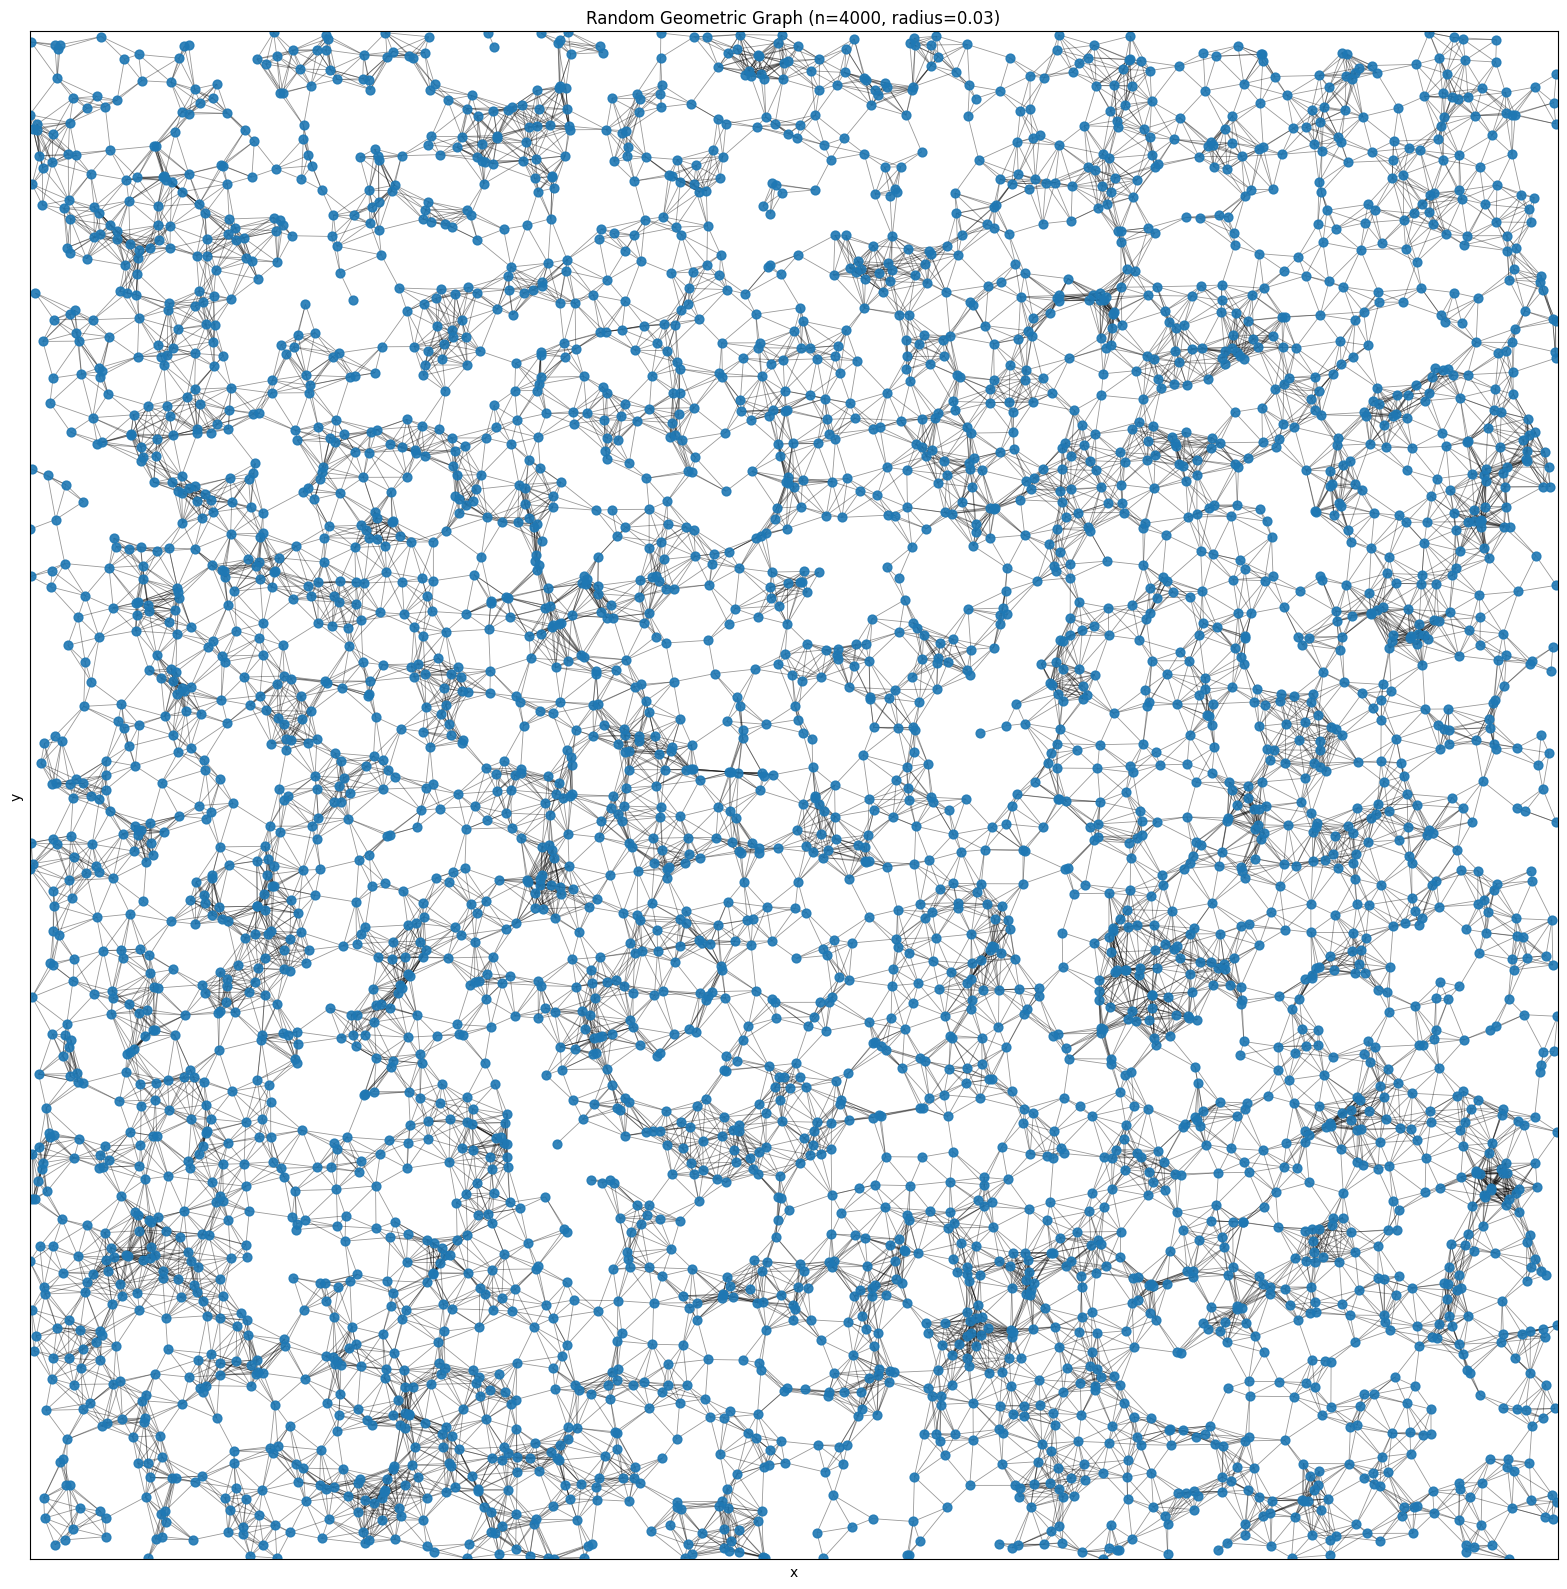

In [4]:
# --- Visualise the RGG in 2D space

# Positions are stored in the 'pos' node attribute by networkx.random_geometric_graph
pos_rgg = nx.get_node_attributes(G_rgg, "pos")

plt.figure(figsize=(16, 16))

# Draw edges first (light)
nx.draw_networkx_edges(
    G_rgg,
    pos_rgg,
    width=0.6,
    alpha=0.4
)

# Draw nodes on top
nx.draw_networkx_nodes(
    G_rgg,
    pos_rgg,
    node_size=40,
    alpha=0.9
)

plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Random Geometric Graph (n={n_rgg}, radius={radius_rgg})")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal", adjustable="box")
#plt.grid(alpha=0.2, linestyle="--")
plt.tight_layout()
plt.show()


Random Geometric Graphs tend to produce **unimodal, approximately Gaussian degree distributions** (see histogram below), particularly at moderate densities where most nodes lie in the interior. This arises because degree is essentially a binomial counting process: each node connects to nearby neighbours within radius $r$. Deviations occur near boundaries and in very sparse graphs, but RGGs do not generate heavy-tailed or hub-dominated structures, unlike the <mark>Barabási–Albert model</mark>.

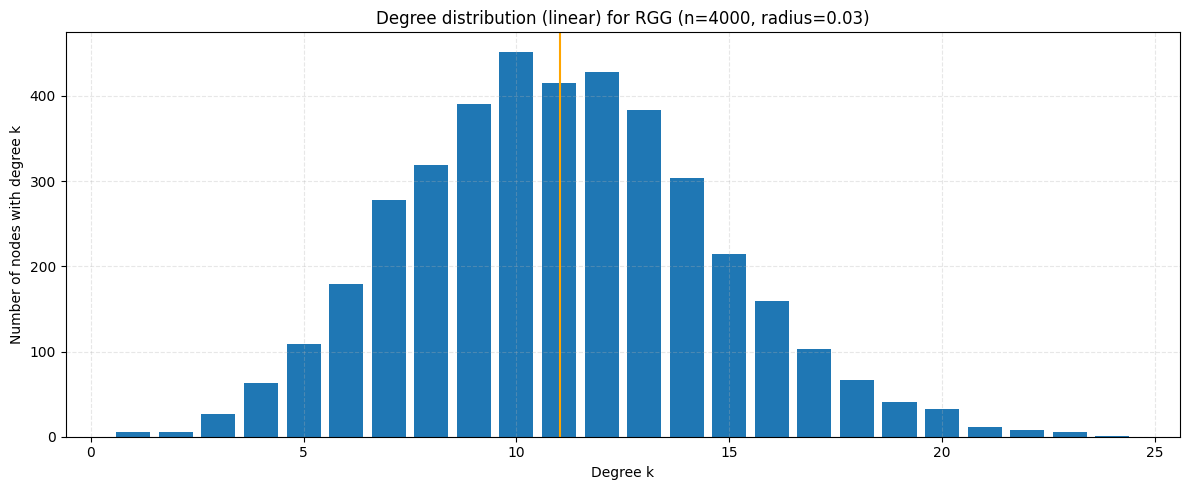

In [5]:
# --- Degree distribution (linear scale) for the RGG

degrees_rgg = [d for _, d in G_rgg.degree()]
deg_counts_rgg = Counter(degrees_rgg)
deg_vals_rgg = np.array(sorted(deg_counts_rgg.keys()))
counts_rgg = np.array([deg_counts_rgg[k] for k in deg_vals_rgg])

plt.figure(figsize=(12, 5))
plt.bar(deg_vals_rgg, counts_rgg, width=0.8, align="center")
plt.xlabel("Degree k")
plt.ylabel("Number of nodes with degree k")
plt.title(f"Degree distribution (linear) for RGG (n={n_rgg}, radius={radius_rgg})")
plt.grid(alpha=0.3, linestyle="--")
plt.axvline(x = np.mean(degrees_rgg), color = "orange")
plt.tight_layout()
plt.show()


### 1.3 Structural interpretation of RGGs

A few observations:

- **Spatial structure is explicit**: nodes live in $[0, 1] \times [0, 1]$, and edges connect nearby nodes.
- The **average degree** depends strongly on the connection radius: increase $r$ and the graph quickly becomes dense and highly connected.
- The **clustering coefficient** is typically high: if A is close to B and C, chances are B and C are also close.
- There is a clear **connectivity threshold**:
  - small $r$: many small components, no giant component;
  - beyond a critical $r$: a large connected component spanning the domain.

Conceptually, this sits between the SOC forest and the abstract networks:

- Like the forest, **geometry matters**: distance controls connectivity.
- Unlike the rigid lattice, node positions are irregular and degree is variable.

From a cascade perspective, these structural properties suggest that:

- Failures are likely to be **localised in space**, spreading primarily through dense neighbourhoods.
- Dense regions may act as local **amplifiers**, while sparse regions function as natural **firebreaks**.
- A small number of spatial “bridge” nodes may connect otherwise separate clusters, enabling larger cascades once a connectivity threshold is crossed.

This is a helpful mental model for IoT meshes, wireless networks, and spatially deployed devices, where both **where** you are and **who** you connect to matter for cyber risk.

---

## 2. Cascade Behaviour in Random Geometric Graphs 

### 2.1 A dynamic variant: growing edges with occasional “lightning”

In the <mark>SOC forest in Notebook 1</mark>, the *sites* (trees) appeared slowly and occasionally a lightning strike would burn a connected cluster.

On a Random Geometric Graph we can build an analogous process:

- Nodes represent fixed devices in space (IoT sensors, controllers, etc.).
- Edges represent active relationships: trust links, communication links, shared credentials.
- Over time, new edges appear as systems are configured, integrated, or granted access.
- Occasionally, a “lightning” event hits a random node:
  - we take the connected component containing that node,
  - measure its size and spatial extent,
  - then remove all edges in that component (a fast “burn”).

> N.B. Node positions remain fixed; only connectivity evolves.

This gives us:

- **Slow drive:** gradual growth of connectivity (edges added one at a time).
- **Fast dissipation:** sudden removal of all edges in a connected region.
- **Observables:** cascade size, edge density over time, and a correlation length
  (radius of gyration of the affected component) defined in physical space.

Conceptually, this is the forest model re-imagined as a spatial network analogue:

> trees → edges  
> grid sites → node positions in the plane  
> burnt tree cluster → erased or compromised connectivity region

It is also a natural mental model for cyber systems where:
- connectivity tends to increase over time, and
- incidents occasionally force local reconfiguration, credential resets,
  or segmentation of affected parts of the network.

---

>### <b>Terminology shift</b>
>
>Having introduced cascade dynamics through the forest-fire analogy, we now transition to standard network language.  
>
>- Nodes represent spatially embedded devices.  
>- Edges represent active relationships.  
>- A sudden removal of a connected component will be treated as a **disturbance event** (such as an attack or a failure), and the affected component as a **cascade**.
>
>This reframing allows the model to be interpreted more directly in the context of cyber and infrastructural systems.

---


### 2.2 Constructing an RGG model

Here we construct a modest-sized RGG with $N = 2000$ and $r = 0.03$:

In [19]:
# --- Defining nodes and edges

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

rng = np.random.default_rng(42)

n_nodes = 2000
radius = 0.03
positions = {i: rng.random(2) for i in range(n_nodes)}  # in [0,1]x[0,1]

# Precompute all admissible pairs (within radius)
node_ids = list(positions.keys())
pairs = []
for i in range(n_nodes):
    xi, yi = positions[i]
    for j in range(i+1, n_nodes):
        xj, yj = positions[j]
        d = np.hypot(xi - xj, yi - yj)
        if d < radius:
            pairs.append((i, j))
pairs = np.array(pairs, dtype=int)

print(len(pairs), "candidate edges available")

5387 candidate edges available


Using the above construction (with reproducible seed $42$), $5387$ candidate edges are available.  
With $N = 2000$ nodes, we aim to observe at least on the order of $N$ cascades to obtain sufficient data for assessing whether slow build-up and rapid dissipation — characteristic of self-organised criticality — emerge in the RGG setting.

To estimate the number of simulation steps required (and therefore approximate runtime), we reason as follows.

Under the assumption that disturbance events occur independently at each step, let:
- $n_C$ denote the number of cascades observed,
- $n_S$ the total number of model steps,
- $P(\Delta)$ the probability that a disturbance event occurs at a given step.

The expected number of cascades is approximately the number of opportunities for disturbance multiplied by the disturbance probability:

$$
\mathbb{E}[n_C] \approx P(\Delta) \cdot n_S
$$

Rearranging gives an estimate for the number of steps required to observe a target number of cascades:

$$
\mathbb{E}[n_S] \approx \frac{n_C}{P(\Delta)}
$$

This provides a simple scaling rule for choosing simulation length before running the full dynamic model.

### 2.3 Running a dynamic SOC-like process on our RGG model

The code below executes a SOC-like process very similar to what was used in <mark>Notebook 1</mark>. It may take tens of minutes, depending on your machine specs. The objects will be saved afterward and will be available to download in the repo $-$ you do not need to run the code block. A description of all the objects are provided in the code.

In [8]:
# --- Dynamic SOC-like process on RGG edges

G_dyn = nx.Graph()
G_dyn.add_nodes_from(node_ids)

p_disturbance = 0.002   # probability of disturbance per step

cascade_sizes = []     # existing: number of edges in the component
edge_counts = []       # existing: edges in whole graph over time

# for further analysis
cascade_subgraphs = []  # list of nx.Graph subgraphs at ignition
cascade_seeds     = []  # disturbance node for each cascade
cascade_steps     = []  # time step when cascade occurred

# track whether cascade started in LCC or not
cascade_sizes_lcc = []
cascade_sizes_nonlcc = []

############################
cascade_target = n_nodes
############################

t = 0
while len(cascade_sizes) < cascade_target:
    # Slow drive: add one random admissible edge that is not yet present
    missing_edges = [tuple(e) for e in pairs if not G_dyn.has_edge(e[0], e[1])]
    if missing_edges:
        u, v = missing_edges[rng.integers(len(missing_edges))]
        G_dyn.add_edge(u, v)

    # Fast dissipation: occasional disturbance
    if rng.random() < p_disturbance and G_dyn.number_of_edges() > 0:
        # --- find largest connected component (LCC) BEFORE the burn
        components = list(nx.connected_components(G_dyn))
        lcc_nodes  = max(components, key=len)
        lcc_set    = set(lcc_nodes)

        # pick a random node
        seed = int(rng.integers(n_nodes))

        # find its connected component
        component  = nx.node_connected_component(G_dyn, seed)
        comp_nodes = list(component)

        # subgraph at ignition (copy so it's not affected by later edits)
        sub = G_dyn.subgraph(comp_nodes).copy()

        # record cascade size (number of edges in that component)
        s = sub.number_of_edges()
        cascade_sizes.append(s)

        # store objects for later analysis
        cascade_subgraphs.append(sub)
        cascade_seeds.append(seed)
        cascade_steps.append(t)

        # tag whether this cascade was a giant-component burn
        if seed in lcc_set:
            cascade_sizes_lcc.append(s)
        else:
            cascade_sizes_nonlcc.append(s)

        # remove all edges in that component
        G_dyn.remove_edges_from(list(sub.edges()))

    # record total edge count after this step
    edge_counts.append(G_dyn.number_of_edges())
    t += 1

print(len(cascade_sizes), "cascades recorded")


(2000, 'cascades recorded')

The following code block saves the model objects generated. **By default, the block is commented out to prevent overwriting the files**.

In [10]:
# # --- Save GSS model objects
# import os
# import pickle

# # -------------------------------------------------------------------
# # Directory setup
# # -------------------------------------------------------------------
# save_dir = "data/notebook2.1/cascade_data"
# os.makedirs(save_dir, exist_ok=True)

# # -------------------------------------------------------------------
# # Objects to save
# # -------------------------------------------------------------------
# objects_to_save = {
#     "cascade_sizes": cascade_sizes,
#     "edge_counts": edge_counts,
#     "cascade_subgraphs": cascade_subgraphs,
#     "cascade_seeds": cascade_seeds,
#     "cascade_steps": cascade_steps,
#     "cascade_sizes_lcc": cascade_sizes_lcc,
#     "cascade_sizes_nonlcc": cascade_sizes_nonlcc,
# }

# # -------------------------------------------------------------------
# # Save each object using its variable name
# # -------------------------------------------------------------------
# for name, obj in objects_to_save.items():
#     filepath = os.path.join(save_dir, f"{name}.pkl")
#     with open(filepath, "wb") as f:
#         pickle.dump(obj, f)

# print(f"Saved {len(objects_to_save)} objects to '{save_dir}'")

Saved 7 objects to 'data/notebook2.1/cascade_data'


---

## 3. Analysis of Cascade Behaviour in the RGG Model

The time series of edge count over the first 50,000 steps exhibits the characteristic slow–fast dynamics built into the model. Connectivity increases gradually through incremental edge formation, punctuated by abrupt drops when disturbance events remove entire connected components. These discontinuities occur without obvious temporal periodicity, indicating that cascades arise stochastically rather than through any imposed scheduling.

The distribution of cascade sizes (measured as the number of edges removed during each disturbance) is strongly skewed. Most cascades are small, while larger events occur progressively less frequently. In linear scale this produces a rapidly decaying histogram, reflecting the predominance of localised failures.

In [11]:
# --- Load GSS model objects
import os
import pickle

# -------------------------------------------------------------------
# Directory containing saved objects
# -------------------------------------------------------------------
load_dir = "data/notebook2.1/cascade_data"

# -------------------------------------------------------------------
# Load all .pkl files and recreate variables
# -------------------------------------------------------------------
for filename in os.listdir(load_dir):
    if filename.endswith(".pkl"):
        var_name = filename[:-4]  # remove ".pkl"
        filepath = os.path.join(load_dir, filename)
        
        with open(filepath, "rb") as f:
            globals()[var_name] = pickle.load(f)

print(f"Loaded objects from '{load_dir}'")

Loaded objects from 'data/notebook2.1/cascade_data'


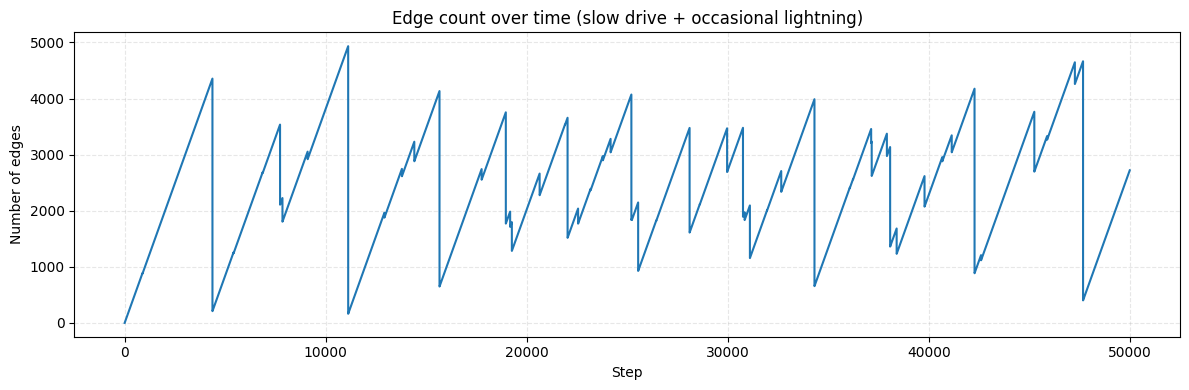

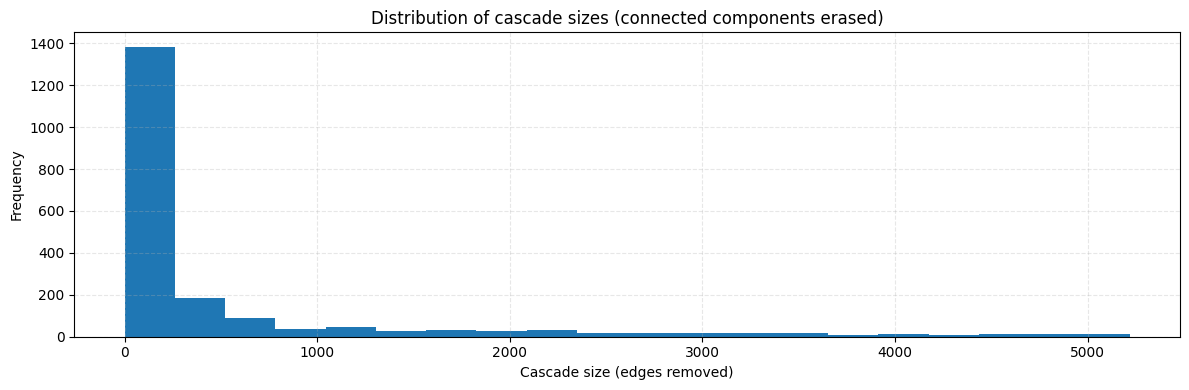

In [14]:
# --- Plots of edge count over time and the distribution of cascade sizes

plt.figure(figsize=(12, 4))
plt.plot(edge_counts[:50000])
plt.xlabel("Step")
plt.ylabel("Number of edges")
plt.title("Edge count over time (slow drive + occasional lightning)")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.hist(cascade_sizes, bins=20)
plt.xlabel("Cascade size (edges removed)")
plt.ylabel("Frequency")
plt.title("Distribution of cascade sizes (connected components erased)")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()


When the cascade size distribution is plotted on log–log axes using logarithmic binning, a clear approximately linear region emerges over a substantial range of sizes. This suggests heavy-tailed behaviour, consistent with scale-free-like cascade statistics in this spatially embedded network. However, the distribution is necessarily bounded above by the finite size of the system, and deviations from linearity appear near the largest events.

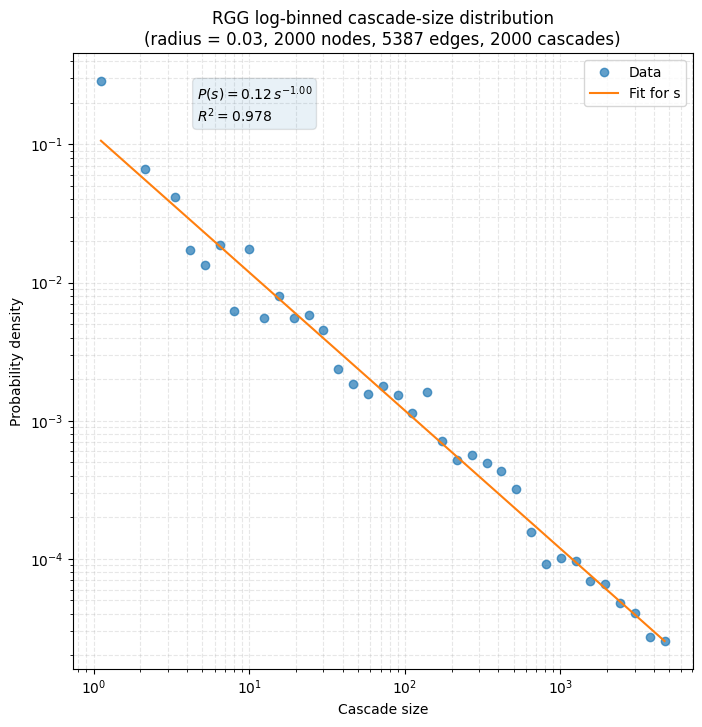

In [ ]:
# --- Plotting cascade size distribution (log-log)

import numpy as np

cascade_sizes_arr = np.array(cascade_sizes)

# Filter positive sizes
sizes = cascade_sizes_arr[cascade_sizes_arr > 0]
N_sizes = len(sizes)

min_size = sizes.min()
max_size = sizes.max()

# Choose, say, 30–40 log bins
n_bins = 40
bins_sizes = np.logspace(np.log10(min_size), np.log10(max_size), n_bins)

counts_sizes, edges_sizes = np.histogram(sizes, bins=bins_sizes)

# Normalised counts (probability per bin)
prob_sizes = counts_sizes / N_sizes

# Geometric mean of bin edges as x-coordinate
centers_sizes = np.sqrt(edges_sizes[:-1] * edges_sizes[1:])

# PDF-like (probability per unit fire size)
bin_widths_sizes = edges_sizes[1:] - edges_sizes[:-1]
pdf_sizes = counts_sizes / (N_sizes * bin_widths_sizes)

mask_sizes = pdf_sizes > 0
centers_sizes_plot = centers_sizes[mask_sizes]
pdf_sizes_plot = pdf_sizes[mask_sizes]

# --- Fit settings for sizes ---
x_max_fit_sizes = 5e3  # limit data used for the fit

mask_fit_sizes = (
    (centers_sizes_plot > 0) &
    (pdf_sizes_plot > 0) &
    (centers_sizes_plot <= x_max_fit_sizes)
)

x_fit_sizes = centers_sizes_plot[mask_fit_sizes]
y_fit_sizes = pdf_sizes_plot[mask_fit_sizes]

log_x_sizes = np.log10(x_fit_sizes)
log_y_sizes = np.log10(y_fit_sizes)

m_sizes, b_sizes = np.polyfit(log_x_sizes, log_y_sizes, 1)
log_y_pred_sizes = m_sizes * log_x_sizes + b_sizes

# R^2 in log space
ss_res_sizes = np.sum((log_y_sizes - log_y_pred_sizes)**2)
ss_tot_sizes = np.sum((log_y_sizes - np.mean(log_y_sizes))**2)
r2_sizes = 1 - ss_res_sizes / ss_tot_sizes

# Convert fitted line back to original space
log_x_line_sizes = np.linspace(log_x_sizes.min(), log_x_sizes.max(), 200)
log_y_line_sizes = m_sizes * log_x_line_sizes + b_sizes

x_line_sizes = 10**log_x_line_sizes
y_line_sizes = 10**log_y_line_sizes

A_sizes = 10**b_sizes  # Power-law prefactor: P(s) ≈ A_sizes * s^m_sizes

# --- Left: cascade size distribution ---
plt.figure(figsize = (8, 8))
plt.loglog(centers_sizes_plot, pdf_sizes_plot, 'o', alpha=0.7, label="Data")
#plt.loglog(x_line_sizes, y_line_sizes, '-', label=f"Fit for s ≤ {x_max_fit_sizes:.0f}")
plt.loglog(x_line_sizes, y_line_sizes, '-', label=f"Fit for s")

# Shade downturn region (beyond fit range)
#x_min_shade_sizes = x_max_fit_sizes
#x_max_shade_sizes = centers_sizes_plot.max()
#plt.axvspan(x_min_shade_sizes, x_max_shade_sizes, color="red", alpha=0.15,
#            label="Finite-size downturn region", zorder=0)

plt.xlabel("Cascade size")
plt.ylabel("Probability density")
plt.title("RGG log-binned cascade-size distribution\n"
              f"(radius = {radius}, {n_nodes} nodes, {len(pairs)} edges, {len(cascade_sizes_arr)} cascades)")
plt.grid(True, which="both", ls="--", alpha=0.3)

eq_text_sizes = (
    r"$P(s) = {:.2g}\,s^{{{:.2f}}}$".format(A_sizes, m_sizes) + "\n" +
    r"$R^2 = {:.3f}$".format(r2_sizes)
)

ax = plt.gca()

plt.text(
    0.2, 0.95, eq_text_sizes,
    transform=ax.transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round", alpha=0.1)
)

plt.legend()

plt.show()


Logarithmic binning reveals a clear approximately linear region in log–log space across a substantial range of cascade sizes. This behaviour is consistent with scale-free-like cascade statistics emerging from the spatial RGG dynamics. Although cascade sizes are necessarily bounded by the finite system size and its geometric constraints, any resulting truncation is not dominant over the observed scaling range.

Taken together, these results indicate that the RGG model, when driven by gradual edge formation and intermittent disturbance, can produce broad cascade size distributions alongside slow accumulation and rapid dissipation dynamics. This provides initial evidence that SOC-like features may arise even in geometrically constrained network structures. Finite-size effects and their implications are examined more carefully in a <mark>later notebook</mark>.

---

## 4. Conclusion

We began by examining the structural properties of a Random Geometric Graph with $N = 4000$ nodes and connection radius $r = 0.03$. The resulting network is sparse but well connected: the average degree is approximately $11$, clustering is high ($\approx 0.60$), and nearly all nodes lie within a single giant component. The network exhibits substantial diameter and path length, reflecting its spatial embedding and local connectivity constraints.

These structural features are important. High clustering and geometric locality produce strongly connected neighbourhoods, while the absence of hub-dominated structure limits extreme degree heterogeneity. The graph therefore represents a spatially constrained but globally connected system.

When driven by gradual edge formation and intermittent disturbance, this a smaller 2000-node RGG produces broad cascade size distributions alongside slow accumulation and rapid dissipation dynamics. Most cascades are small and localised, yet occasional large events occur, generating an approximately linear region in the log–log cascade size distribution over a substantial range. Although the system is finite and deviations appear at the largest scales, the observed behaviour is consistent with SOC-like cascade dynamics emerging in a spatial network.

This notebook provides a proof-of-concept demonstration that SOC-like cascade statistics can emerge in a spatially embedded Random Geometric Graph under slow edge accumulation and intermittent disturbance. The objective here is illustrative rather than exhaustive. In subsequent notebooks, we examine robustness across system size $N$, driving increment $\Delta$ and related parameters, analyse spatial extent measures and finite-size effects in greater detail, and compare the behaviour with that of non-spatial random networks.

---